In [30]:
#import packages

import pandas as pd
import numpy as np

#claims data
DATA_PATH = "finalapi.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

#load data

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
display(df_raw.head())

#schema inspection

print("\nColumns:")
print(df_raw.dtypes)

print("\nMissing value counts (top 25):")
display(df_raw.isna().sum().sort_values(ascending=False).head(25))

#column setup

key_cols = [
    "AGENCY_ID",
    "PRIMARY_AGENCY_ID",
    "PROD_ABBR",
    "PROD_LINE",
    "STATE_ABBR",
    "STAT_PROFILE_DATE_YEAR",
    "RETENTION_POLY_QTY",
    "POLY_INFORCE_QTY",
    "NB_WRTN_PREM_AMT",
    "WRTN_PREM_AMT",
    "PREV_WRTN_PREM_AMT",
    "PRD_INCRD_LOSSES_AMT",
    "RETENTION_RATIO",
    "LOSS_RATIO_3YR",
    "GROWTH_RATE_3YR"
]

existing_key_cols = [c for c in key_cols if c in df_raw.columns]
print("\nSummary of selected numeric fields:")
display(df_raw[existing_key_cols].describe(include="all").T)

df = df_raw.copy()


if "STAT_PROFILE_DATE_YEAR" in df.columns:
    df["STAT_PROFILE_DATE_YEAR"] = pd.to_numeric(df["STAT_PROFILE_DATE_YEAR"], errors="coerce").astype("Int64")

numeric_candidate_cols = [
    "RETENTION_POLY_QTY",
    "POLY_INFORCE_QTY",
    "PREV_POLY_INFORCE_QTY",
    "NB_WRTN_PREM_AMT",
    "WRTN_PREM_AMT",
    "PREV_WRTN_PREM_AMT",
    "PRD_ERND_PREM_AMT",
    "PRD_INCRD_LOSSES_AMT",
    "RETENTION_RATIO",
    "LOSS_RATIO_3YR",
    "GROWTH_RATE_3YR"
]

for col in numeric_candidate_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nClean copy shape:", df.shape)

print("\nSample PROD_LINE values:", df["PROD_LINE"].dropna().unique()[:10] if "PROD_LINE" in df.columns else "N/A")
print("\nSample STATE_ABBR values:", df["STATE_ABBR"].dropna().unique()[:10] if "STATE_ABBR" in df.columns else "N/A")


Raw shape: (213328, 49)


,AGENCY_ID,PRIMARY_AGENCY_ID,PROD_ABBR,PROD_LINE,STATE_ABBR,STAT_PROFILE_DATE_YEAR,RETENTION_POLY_QTY,POLY_INFORCE_QTY,PREV_POLY_INFORCE_QTY,NB_WRTN_PREM_AMT,WRTN_PREM_AMT,PREV_WRTN_PREM_AMT,PRD_ERND_PREM_AMT,PRD_INCRD_LOSSES_AMT,MONTHS,RETENTION_RATIO,LOSS_RATIO,LOSS_RATIO_3YR,GROWTH_RATE_3YR,AGENCY_APPOINTMENT_YEAR,ACTIVE_PRODUCERS,MAX_AGE,MIN_AGE,VENDOR_IND,VENDOR,PL_START_YEAR,PL_END_YEAR,COMMISIONS_START_YEAR,COMMISIONS_END_YEAR,CL_START_YEAR,CL_END_YEAR,ACTIVITY_NOTES_START_YEAR,ACTIVITY_NOTES_END_YEAR,CL_BOUND_CT_MDS,CL_QUO_CT_MDS,CL_BOUND_CT_SBZ,CL_QUO_CT_SBZ,CL_BOUND_CT_eQT,CL_QUO_CT_eQT,PL_BOUND_CT_ELINKS,PL_QUO_CT_ELINKS,PL_BOUND_CT_PLRANK,PL_QUO_CT_PLRANK,PL_BOUND_CT_eQTte,PL_QUO_CT_eQTte,PL_BOUND_CT_APPLIED,PL_QUO_CT_APPLIED,PL_BOUND_CT_TRANSACTNOW,PL_QUO_CT_TRANSACTNOW
0,3,3,BOILERMACH,CL,IN,2005,0,0,0,40.0000,"3,074.6300",149.0000,"3,005.7700",0.0000,8,"99,999.0000",0.0000,"99,999.0000","99,999.0000",1957,14,85,48,N,Unknown,99999,99999,99999,99999,99999,99999,99999,99999,0,1,0,0,0,0,0,0,0,103,50,288,0,0,0,0
1,3,3,BOILERMACH,CL,IN,2006,0,0,0,151.0000,"6,562.2800","5,438.5500","6,433.4400",0.0000,12,"99,999.0000",0.0000,0.6954,"99,999.0000",1957,14,85,48,N,Unknown,99999,99999,99999,99999,99999,99999,99999,99999,0,1,0,0,0,0,0,0,0,103,50,288,0,0,0,0
2,3,3,BOILERMACH,CL,IN,2007,0,0,0,40.0000,"6,205.1100","6,562.2800","6,357.0900",0.0000,12,"99,999.0000",0.0000,0.4727,"99,999.0000",1957,14,85,48,N,Unknown,99999,99999,99999,99999,99999,99999,99999,99999,0,1,0,0,0,0,0,0,0,103,50,288,0,0,0,0
3,3,3,BOILERMACH,CL,IN,2008,0,0,0,69.0000,"5,159.8900","6,205.1100","5,315.0100",0.0000,12,"99,999.0000",0.0000,0.4458,-0.0829,1957,14,85,48,N,Unknown,99999,99999,99999,99999,99999,99999,99999,99999,0,1,0,0,0,0,0,0,0,103,50,288,0,0,0,0
4,3,3,BOILERMACH,CL,IN,2009,0,0,0,28.0000,"4,527.7100","5,159.8900","4,706.4700",0.0000,12,"99,999.0000",0.0000,0.3377,-0.1481,1957,14,85,48,N,Unknown,99999,99999,99999,99999,99999,99999,99999,99999,0,1,0,0,0,0,0,0,0,103,50,288,0,0,0,0



Columns:
AGENCY_ID                      int64
PRIMARY_AGENCY_ID              int64
PROD_ABBR                     object
PROD_LINE                     object
STATE_ABBR                    object
STAT_PROFILE_DATE_YEAR         int64
RETENTION_POLY_QTY             int64
POLY_INFORCE_QTY               int64
PREV_POLY_INFORCE_QTY          int64
NB_WRTN_PREM_AMT             float64
WRTN_PREM_AMT                float64
PREV_WRTN_PREM_AMT           float64
PRD_ERND_PREM_AMT            float64
PRD_INCRD_LOSSES_AMT         float64
MONTHS                         int64
RETENTION_RATIO              float64
LOSS_RATIO                   float64
LOSS_RATIO_3YR               float64
GROWTH_RATE_3YR              float64
AGENCY_APPOINTMENT_YEAR        int64
ACTIVE_PRODUCERS               int64
MAX_AGE                        int64
MIN_AGE                        int64
VENDOR_IND                    object
VENDOR                        object
PL_START_YEAR                  int64
PL_END_YEAR                 

AGENCY_ID                  0
PRIMARY_AGENCY_ID          0
PROD_ABBR                  0
PROD_LINE                  0
STATE_ABBR                 0
STAT_PROFILE_DATE_YEAR     0
RETENTION_POLY_QTY         0
POLY_INFORCE_QTY           0
PREV_POLY_INFORCE_QTY      0
NB_WRTN_PREM_AMT           0
WRTN_PREM_AMT              0
PREV_WRTN_PREM_AMT         0
PRD_ERND_PREM_AMT          0
PRD_INCRD_LOSSES_AMT       0
MONTHS                     0
RETENTION_RATIO            0
LOSS_RATIO                 0
LOSS_RATIO_3YR             0
GROWTH_RATE_3YR            0
AGENCY_APPOINTMENT_YEAR    0
ACTIVE_PRODUCERS           0
MAX_AGE                    0
MIN_AGE                    0
VENDOR_IND                 0
VENDOR                     0
dtype: int64


Summary of selected numeric fields:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AGENCY_ID,"213,328.0000",NaN,NaN,NaN,"4,978.9642","2,928.0276",3.0000,"2,366.0000","4,976.0000","7,589.0000","9,998.0000"
PRIMARY_AGENCY_ID,"213,328.0000",NaN,NaN,NaN,"21,840.9822","36,410.3554",3.0000,"2,788.0000","6,110.0000","9,285.0000","99,999.0000"
PROD_ABBR,213328,28,GENERALIAB,15254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PROD_LINE,213328,2,CL,124692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATE_ABBR,213328,6,OH,101323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STAT_PROFILE_DATE_YEAR,"213,328.0000",NaN,NaN,NaN,"2,010.1917",3.1291,"2,005.0000","2,008.0000","2,010.0000","2,013.0000","2,015.0000"
RETENTION_POLY_QTY,"213,328.0000",NaN,NaN,NaN,158.6345,718.7663,0.0000,0.0000,0.0000,24.0000,"21,979.0000"
POLY_INFORCE_QTY,"213,328.0000",NaN,NaN,NaN,175.6169,774.6409,0.0000,0.0000,0.0000,30.0000,"22,968.0000"
NB_WRTN_PREM_AMT,"213,328.0000",NaN,NaN,NaN,"2,243.6514","9,976.8017",0.0000,0.0000,0.0000,485.0000,"556,930.2200"
WRTN_PREM_AMT,"213,328.0000",NaN,NaN,NaN,"19,632.6838","66,443.9545","-202,777.6000",2.0275,"1,143.6200","8,358.6950","1,715,741.7700"



Clean copy shape: (213328, 49)

Sample PROD_LINE values: ['CL' 'PL']

Sample STATE_ABBR values: ['IN' 'KY' 'MI' 'OH' 'PA' 'WV']


In [34]:
#replace 9 placeholders with NaN

PLACEHOLDER_VALUES = [99999, 99999.0]

df_clean = df.replace(PLACEHOLDER_VALUES, np.nan)

print("After placeholder cleanup, shape:", df_clean.shape)

#row placement

df_clean["EXPOSURE_CELL"] = 1

#rows that have earned premium and incurred losses

df_clean["HAS_PREMIUM"] = np.where(df_clean["PRD_ERND_PREM_AMT"].notna() &
                                   (df_clean["PRD_INCRD_LOSSES_AMT"] > 0), 1, 0)
df_clean["HAS_LOSS"] = np.where(df_clean["PRD_INCRD_LOSSES_AMT"].notna() &
                                (df_clean["PRD_INCRD_LOSSES_AMT"] > 0), 1, 0)

for col in ["LOSS_RATIO", "LOSS_RATIO_3YR", "RETENTION_RATIO", "GROWTH_RATE_3YR"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(float)
        df_clean[col] = df_clean[col].clip(lower=-5, upper=5)

#i think it's a good idea to have one row per agency_id, prod_line, prod_abbr, state_abbr, stat_profile_date_year for kpi understanding

group_keys = [
    "AGENCY_ID",
    "PRIMARY_AGENCY_ID",
    "PROD_LINE",
    "PROD_ABBR",
    "STATE_ABBR",
    "STAT_PROFILE_DATE_YEAR"
]

agg_dict = {
    "RETENTION_POLY_QTY": "sum",
    "POLY_INFORCE_QTY": "sum",
    "PREV_POLY_INFORCE_QTY": "sum",
    "NB_WRTN_PREM_AMT": "sum",
    "WRTN_PREM_AMT": "sum",
    "PREV_WRTN_PREM_AMT": "sum",
    "PRD_ERND_PREM_AMT": "sum",
    "PRD_INCRD_LOSSES_AMT": "sum",
    "EXPOSURE_CELL": "sum",
    "HAS_PREMIUM": "sum",
    "HAS_LOSS": "sum",
}

agg_dict = {k: v for k, v in agg_dict.items() if k in df_clean.columns}

kpi = (
    df_clean
    .groupby(group_keys, dropna=False)
    .agg(agg_dict)
    .reset_index()
)

print("KPI cube shape:", kpi.shape)
display(kpi.head())

# a test retention policy quantity rate calculation

if {"RETENTION_POLY_QTY", "POLY_INFORCE_QTY"}.issubset(kpi.columns):
    kpi["RETENTION_RATE_POLY"] = np.where(
        kpi["POLY_INFORCE_QTY"] > 0,
        kpi["RETENTION_POLY_QTY"] / kpi["POLY_INFORCE_QTY"],
        np.nan
    )

#growth in written premium vs premium period

if {"WRTN_PREM_AMT", "PREV_WRTN_PREM_AMT"}.issubset(kpi.columns):
    kpi["PREMIUM_GROWTH_RATE"] = np.where(
        kpi["PREV_WRTN_PREM_AMT"] > 0,
        (kpi["WRTN_PREM_AMT"] - kpi["PREV_WRTN_PREM_AMT"]) / kpi["PREV_WRTN_PREM_AMT"],
        np.nan
    )

#loss ratio at cube level: incurred losses / earned premium

if {"PRD_INCRD_LOSSES_AMT", "PRD_ERND_PREM_AMT"}.issubset(kpi.columns):
    kpi["LOSS_RATIO_CALC"] = np.where(
        kpi["PRD_ERND_PREM_AMT"] > 0,
        kpi["PRD_INCRD_LOSSES_AMT"] / kpi["PRD_ERND_PREM_AMT"],
        np.nan
    )


#average written premium per policy

if "POLY_INFORCE_QTY" in kpi.columns:
    kpi["AVG_POLY_INFORCE_PER_CELL"] = np.where(
        kpi["EXPOSURE_CELL"] > 0,
        kpi["WRTN_PREM_AMT"] / kpi["EXPOSURE_CELL"],
        np.nan
    )

if "WRTN_PREM_AMT" in kpi.columns:
    kpi["AVG_WRTN_PREM_PER_CELL"] = np.where(
        kpi["EXPOSURE_CELL"] > 0,
        kpi["WRTN_PREM_AMT"] / kpi["EXPOSURE_CELL"],
        np.nan
    )

#checks

print("\nTop 10 agency/product/year cells by written premium:")
display(
    kpi.sort_values("WRTN_PREM_AMT", ascending=False).head(10)[[
    "AGENCY_ID",
    "PROD_LINE",
    "PROD_ABBR",
    "STATE_ABBR",
    "STAT_PROFILE_DATE_YEAR",
    "WRTN_PREM_AMT",
    "PRD_ERND_PREM_AMT",
    "PRD_INCRD_LOSSES_AMT",
    "LOSS_RATIO_CALC",
    "RETENTION_RATE_POLY",
    "PREMIUM_GROWTH_RATE"
    ]]
    
)

print("\nRandom sample of rows:")
display(kpi.sample(10, random_state=42))

#save for Tableau implementation

df_clean.to_csv("finalapi_clean.csv", index=False)
kpi.to_csv("finalapi_kpi_cube.csv", index=False)

print("\nSaved:")
print(" finalapi_clean.csv     (row-level cleaned data)")
print(" finalapi_kpi_cube.csv  (agency/product/state/year KPI cube data)")


After placeholder cleanup, shape: (213328, 49)
KPI cube shape: (213328, 17)


,AGENCY_ID,PRIMARY_AGENCY_ID,PROD_LINE,PROD_ABBR,STATE_ABBR,STAT_PROFILE_DATE_YEAR,RETENTION_POLY_QTY,POLY_INFORCE_QTY,PREV_POLY_INFORCE_QTY,NB_WRTN_PREM_AMT,WRTN_PREM_AMT,PREV_WRTN_PREM_AMT,PRD_ERND_PREM_AMT,PRD_INCRD_LOSSES_AMT,EXPOSURE_CELL,HAS_PREMIUM,HAS_LOSS
0,3,3.0000,CL,BOILERMACH,IN,2005,0,0,0.0000,40.0000,"3,074.6300",149.0000,"3,005.7700",0.0000,1,0,0
1,3,3.0000,CL,BOILERMACH,IN,2006,0,0,0.0000,151.0000,"6,562.2800","5,438.5500","6,433.4400",0.0000,1,0,0
2,3,3.0000,CL,BOILERMACH,IN,2007,0,0,0.0000,40.0000,"6,205.1100","6,562.2800","6,357.0900",0.0000,1,0,0
3,3,3.0000,CL,BOILERMACH,IN,2008,0,0,0.0000,69.0000,"5,159.8900","6,205.1100","5,315.0100",0.0000,1,0,0
4,3,3.0000,CL,BOILERMACH,IN,2009,0,0,0.0000,28.0000,"4,527.7100","5,159.8900","4,706.4700",0.0000,1,0,0



Top 10 agency/product/year cells by written premium:


,AGENCY_ID,PROD_LINE,PROD_ABBR,STATE_ABBR,STAT_PROFILE_DATE_YEAR,WRTN_PREM_AMT,PRD_ERND_PREM_AMT,PRD_INCRD_LOSSES_AMT,LOSS_RATIO_CALC,RETENTION_RATE_POLY,PREMIUM_GROWTH_RATE
11201,586,PL,ANNIV,OH,2006,"1,715,741.7700","1,780,498.1600","561,433.9300",0.3153,0.9569,-0.0991
20318,886,PL,ANNIV,WV,2009,"1,694,113.6400","1,676,142.4800","1,177,798.2600",0.7027,0.9420,0.0124
20319,886,PL,ANNIV,WV,2010,"1,687,310.1700","1,679,555.4600","1,257,536.3700",0.7487,0.9594,-0.0040
20317,886,PL,ANNIV,WV,2008,"1,673,446.3400","1,676,740.3600","1,142,569.2000",0.6814,0.9348,0.0314
20320,886,PL,ANNIV,WV,2011,"1,648,580.5800","1,661,406.6500","1,182,694.1400",0.7119,0.9688,-0.0230
20316,886,PL,ANNIV,WV,2007,"1,622,434.9300","1,596,683.7100","721,488.9000",0.4519,0.9259,0.0734
209119,9733,PL,ANNIV,OH,2006,"1,589,187.8200","1,571,762.2800","491,481.8700",0.3127,0.9215,0.0325
11202,586,PL,ANNIV,OH,2007,"1,557,773.0000","1,587,062.5200","535,052.7800",0.3371,0.9826,-0.0921
209120,9733,PL,ANNIV,OH,2007,"1,543,689.5400","1,561,097.7000","807,210.2600",0.5171,0.9569,-0.0286
20315,886,PL,ANNIV,WV,2006,"1,511,471.1800","1,504,325.7200","625,167.6700",0.4156,0.9284,-0.0157



Random sample of rows:


,AGENCY_ID,PRIMARY_AGENCY_ID,PROD_LINE,PROD_ABBR,STATE_ABBR,STAT_PROFILE_DATE_YEAR,RETENTION_POLY_QTY,POLY_INFORCE_QTY,PREV_POLY_INFORCE_QTY,NB_WRTN_PREM_AMT,WRTN_PREM_AMT,PREV_WRTN_PREM_AMT,PRD_ERND_PREM_AMT,PRD_INCRD_LOSSES_AMT,EXPOSURE_CELL,HAS_PREMIUM,HAS_LOSS,RETENTION_RATE_POLY,PREMIUM_GROWTH_RATE,LOSS_RATIO_CALC,AVG_POLY_INFORCE_PER_CELL,AVG_WRTN_PREM_PER_CELL
3063,156,156.0000,PL,MOTORHOM12,OH,2015,5,10,5.0000,0.0000,0.0000,0.0000,266.0500,0.0000,1,0,0,0.5000,NaN,0.0000,0.0000,0.0000
36078,1673,"3,467.0000",PL,DWELLFIRE,OH,2005,165,240,202.0000,"4,410.0000","10,483.9200","8,824.8300","8,399.5500",0.0000,1,0,0,0.6875,0.1880,0.0000,"10,483.9200","10,483.9200"
116693,5540,811.0000,PL,YACHT,IN,2006,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,NaN,NaN,NaN,0.0000,0.0000
82441,3680,"3,680.0000",CL,FIREALLIED,OH,2015,0,0,0.0000,"2,127.0000","19,419.9800","14,669.0000","9,886.9800",0.0000,1,0,0,NaN,0.3239,0.0000,"19,419.9800","19,419.9800"
3091,156,156.0000,PL,SNOWMOBILE,OH,2010,0,5,4.0000,0.0000,0.0000,71.0000,60.0800,0.0000,1,0,0,0.0000,-1.0000,0.0000,0.0000,0.0000
117311,5550,"4,357.0000",CL,BOP,KY,2011,0,0,0.0000,0.0000,"1,642.0000","1,542.0000","1,622.0800",0.0000,1,0,0,NaN,0.0649,0.0000,"1,642.0000","1,642.0000"
172726,8157,"8,157.0000",CL,CRIME,KY,2008,0,0,0.0000,"4,005.5400","6,644.0100","2,638.4700","3,310.6300",0.0000,1,0,0,NaN,1.5181,0.0000,"6,644.0100","6,644.0100"
84318,3815,"3,815.0000",CL,COMMAUTO,IN,2010,0,0,0.0000,0.0000,"25,236.7600","43,635.1200","26,461.1000",-189.9300,1,0,0,NaN,-0.4216,-0.0072,"25,236.7600","25,236.7600"
140114,6557,"8,959.0000",CL,GENERALIAB,OH,2014,0,0,0.0000,0.0000,663.5200,"3,635.2600",410.3700,0.0000,1,0,0,NaN,-0.8175,0.0000,663.5200,663.5200
68128,3072,"3,072.0000",CL,GARAGE,KY,2014,0,0,0.0000,0.0000,"3,736.1400","3,569.0300","3,703.6000",0.0000,1,0,0,NaN,0.0468,0.0000,"3,736.1400","3,736.1400"



Saved:
 finalapi_clean.csv     (row-level cleaned data)
 finalapi_kpi_cube.csv  (agency/product/state/year KPI cube data)


KPI EDA shape: (213328, 26)

Profit class distribution:
PROFIT_CLASS
Weak       79375
Unknown    61476
Strong     46335
Stable     26142
Name: count, dtype: int64

Top products by written premium:


PROD_ABBR
ANNIV        1,351,740,354.9500
HOMEOWNERS     894,963,399.2500
COMMAUTO       469,056,576.3100
GENERALIAB     339,866,909.5400
FIREALLIED     304,490,501.1100
WORKCOMP       181,836,069.9700
GARAGE         132,597,425.6300
COMMUMBREL     105,406,923.7400
ANNIV   12      96,217,551.7700
BOP             83,466,476.5500
Name: WRTN_PREM_AMT, dtype: float64


Top states by written premium:


STATE_ABBR
OH   2,450,301,680.4200
PA     554,895,064.6400
KY     491,799,452.5500
IN     454,687,966.9300
WV     190,866,644.9500
MI      45,650,354.0300
Name: WRTN_PREM_AMT, dtype: float64


Top 15 agencies by written premium:


,AGENCY_ID,WRTN_PREM_AMT,PRD_ERND_PREM_AMT,PRD_INCRD_LOSSES_AMT,EXPOSURE_CELL,LOSS_RATIO_AGENCY
873,5468,"46,079,054.0700","45,758,573.7800","26,977,803.5900",384,0.5896
1589,9733,"33,777,988.7700","33,824,063.5300","22,123,554.7500",540,0.6541
288,1786,"32,761,878.0600","32,406,632.9500","15,189,582.9600",557,0.4687
143,886,"31,047,109.8600","30,708,548.4200","16,774,355.1900",412,0.5462
1356,8365,"29,442,920.6900","28,606,289.7100","16,908,980.4900",496,0.5911
1520,9362,"28,675,251.1800","28,059,479.3300","20,633,911.6100",679,0.7354
716,4351,"26,006,117.6300","25,573,355.0900","11,271,238.3900",534,0.4407
1404,8652,"25,909,071.0900","25,457,040.5800","14,823,914.6800",519,0.5823
1593,9761,"25,433,242.9300","25,348,847.1900","15,288,196.7500",338,0.6031
83,562,"25,116,238.1200","24,759,419.4900","10,727,560.0300",416,0.4333



Agencies with highest loss ratio (min premium filter to avoid noise):


,AGENCY_ID,WRTN_PREM_AMT,PRD_ERND_PREM_AMT,PRD_INCRD_LOSSES_AMT,EXPOSURE_CELL,LOSS_RATIO_AGENCY
1246,7738,"3,411,505.4400","3,580,381.0400","6,587,621.8900",209,1.8399
1182,7391,"3,735,829.4400","3,709,213.6900","5,490,139.9600",212,1.4801
497,3096,"4,212,477.8300","4,150,343.2100","4,833,385.5800",238,1.1646
1480,9097,"11,163,495.7700","10,855,930.0100","11,644,812.9800",216,1.0727
589,3663,"4,049,121.2300","4,117,993.8600","4,396,139.1700",158,1.0675
892,5554,"6,485,484.5900","6,423,691.1600","6,718,814.7700",211,1.0459
960,5938,"13,556,405.1900","13,532,060.3100","13,821,505.5000",305,1.0214
973,6011,"3,520,145.7100","3,426,911.6200","3,406,136.4300",201,0.9939
24,156,"9,980,694.4800","10,167,096.4000","9,768,534.7800",397,0.9608
146,915,"3,898,659.4500","3,949,396.9300","3,778,174.2600",247,0.9566


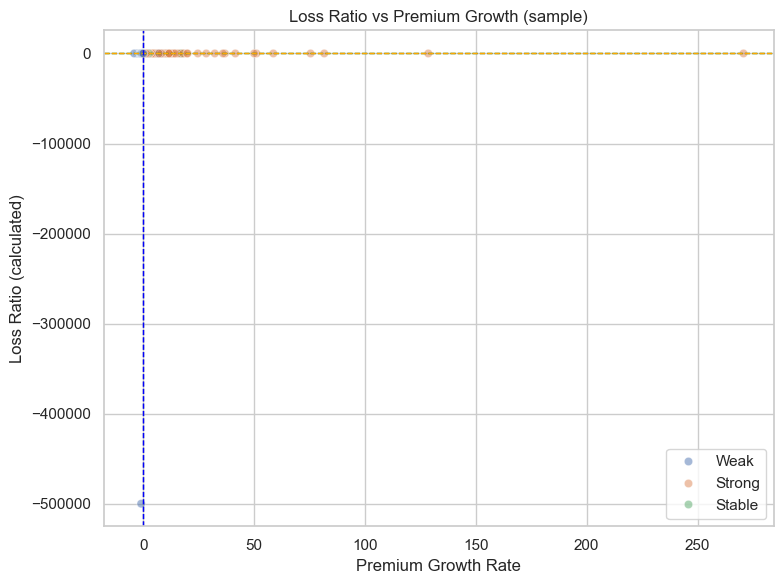

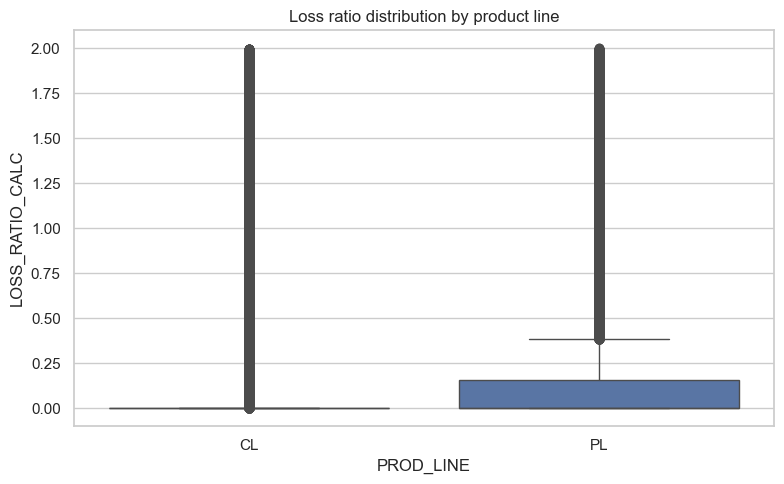

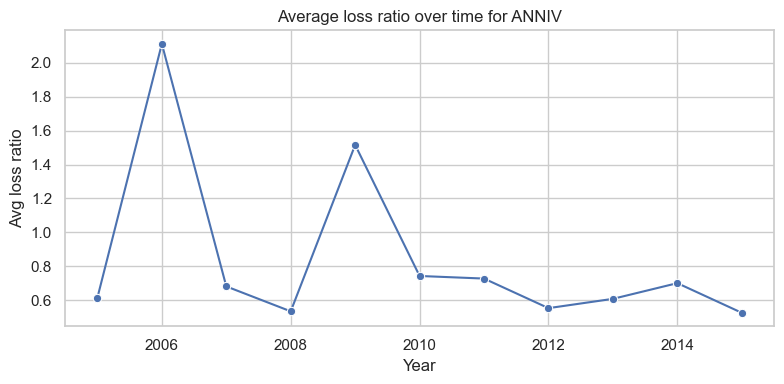


Saved enriched KPI cube to finalapi_kpi_cube_eda.csv


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

kpi_eda = kpi.copy()

#testing feature engineering ideas, earned premium minus incurred losses

if {"PRD_ERND_PREM_AMT", "PRD_INCRD_LOSSES_AMT"}.issubset(kpi_eda.columns):
    kpi_eda["UNDERWRITING_RESULT"] = (
        kpi_eda["PRD_ERND_PREM_AMT"] - kpi_eda["PRD_INCRD_LOSSES_AMT"]
    )

kpi_eda["UW_MARGIN_RATIO"] = np.where(
    kpi_eda["PRD_ERND_PREM_AMT"] > 0,
    kpi_eda["UNDERWRITING_RESULT"] / kpi_eda["PRD_ERND_PREM_AMT"],
    np.nan
)

#indicator for commercial vs personal

if "PROD_LINE" in kpi_eda.columns:
    kpi_eda["IS COMMERCIAL"] = np.where(
        kpi_eda["STAT_PROFILE_DATE_YEAR"] < 2010,
        "Pre-2010",
        "2010+"
    )

#loss ratio & growth

def classify_profit(row):
    lr = row.get("LOSS_RATIO_CALC", np.nan)
    gr = row.get("PREMIUM_GROWTH_RATE", np.nan)

    if pd.isna(lr) or pd.isna(gr):
        return "Unknown"
    if (lr <= 0.6) and (gr >= 0.05):
        return "Strong"
    if (lr <= 0.8) and (gr >= 0.00):
        return "Stable"
    return "Weak"

if {"LOSS_RATIO_CALC", "PREMIUM_GROWTH_RATE"}.issubset(kpi_eda.columns):
    kpi_eda["PROFIT_CLASS"] = kpi_eda.apply(classify_profit, axis=1)

#overview

print("KPI EDA shape:", kpi_eda.shape)
print("\nProfit class distribution:")
if "PROFIT_CLASS" in kpi_eda.columns:
    print(kpi_eda["PROFIT_CLASS"].value_counts(dropna=False))

print("\nTop products by written premium:")
display(
    kpi_eda.groupby("PROD_ABBR", dropna=False)["WRTN_PREM_AMT"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop states by written premium:")
display(
    kpi_eda.groupby("STATE_ABBR", dropna=False)["WRTN_PREM_AMT"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

#diag tests

agency_rollup = (
    kpi_eda.groupby(["AGENCY_ID"], dropna=False)
    .agg({
        "WRTN_PREM_AMT": "sum",
        "PRD_ERND_PREM_AMT": "sum",
        "PRD_INCRD_LOSSES_AMT": "sum",
        "EXPOSURE_CELL": "sum"
    })
    .reset_index()
)

agency_rollup["LOSS_RATIO_AGENCY"] = np.where(
    agency_rollup["PRD_ERND_PREM_AMT"] > 0,
    agency_rollup["PRD_INCRD_LOSSES_AMT"] / agency_rollup["PRD_ERND_PREM_AMT"],
    np.nan
)

print("\nTop 15 agencies by written premium:")
display(
    agency_rollup.sort_values("WRTN_PREM_AMT", ascending=False).head(15)
)

print("\nAgencies with highest loss ratio (min premium filter to avoid noise):")
premium_threshold = agency_rollup["PRD_ERND_PREM_AMT"].quantile(0.75)
display(
    agency_rollup[agency_rollup["PRD_ERND_PREM_AMT"] >= premium_threshold]
    .sort_values("LOSS_RATIO_AGENCY", ascending=False).head(15)
)

#visual eda

sns.set(style="whitegrid")

#loss ratio vs premium growth scatter plot

if {"LOSS_RATIO_CALC", "PREMIUM_GROWTH_RATE"}.issubset(kpi_eda.columns):
    plt.figure(figsize=(8, 6))
    sample_for_scatter = kpi_eda.dropna(subset=["LOSS_RATIO_CALC", "PREMIUM_GROWTH_RATE"])
    sample_for_scatter = sample_for_scatter.sample(
        min(5000, len(sample_for_scatter))
    )
    sns.scatterplot(
        data=sample_for_scatter,
        x="PREMIUM_GROWTH_RATE",
        y="LOSS_RATIO_CALC",
        hue="PROFIT_CLASS" if "PROFIT_CLASS" in kpi_eda.columns else None,
        alpha=0.5
    )
    plt.axhline(0.6, color="green", linestyle="--", linewidth=1)
    plt.axhline(0.8, color="orange", linestyle="--", linewidth=1)
    plt.axvline(0.0, color='gray', linestyle='--', linewidth=1)
    plt.axvline(0.05, color="blue", linestyle="--", linewidth=1)
    plt.title("Loss Ratio vs Premium Growth (sample)")
    plt.xlabel("Premium Growth Rate")
    plt.ylabel("Loss Ratio (calculated)")
    plt.legend()
    plt.tight_layout()
    plt.show()

#boxplot of loss ratio by product line

if {"LOSS_RATIO_CALC", "PROD_LINE"}.issubset(kpi_eda.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=kpi_eda[(kpi_eda["LOSS_RATIO_CALC"].notna()) &
                     (kpi_eda["LOSS_RATIO_CALC"].between(0, 2))],
        x="PROD_LINE",
        y="LOSS_RATIO_CALC"
    )
    plt.title("Loss ratio distribution by product line")
    plt.tight_layout()
    plt.show()

#average loss ratio by year for top product

if {"LOSS_RATIO_CALC", "STAT_PROFILE_DATE_YEAR", "PROD_ABBR"}.issubset(kpi_eda.columns):
    top_prod = (
        kpi_eda.groupby("PROD_ABBR", dropna=False)["WRTN_PREM_AMT"]
        .sum()
        .sort_values(ascending=False)
        .index[0]
    )
    trend = (
        kpi_eda[kpi_eda["PROD_ABBR"] == top_prod]
        .groupby("STAT_PROFILE_DATE_YEAR", dropna=False) ["LOSS_RATIO_CALC"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=trend, x="STAT_PROFILE_DATE_YEAR", y="LOSS_RATIO_CALC", marker="o")
    plt.title(f"Average loss ratio over time for {top_prod}")
    plt.xlabel("Year")
    plt.ylabel("Avg loss ratio")
    plt.tight_layout()
    plt.show()

#cube for modeling

kpi_eda.to_csv("finalapi_kpi_cube_eda.csv", index=False)
print("\nSaved enriched KPI cube to finalapi_kpi_cube_eda.csv")     
        